# importing libs and pkgs

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms.v2 as v2

from torch.utils.data import Dataset , DataLoader
from torch.random import Generator
device = "cuda" if torch.cuda.is_available() else "cpu"

import numpy as np
np.random.seed(58)
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
from kagglehub import KaggleDatasetAdapter
#kagglehub.login()
from tqdm import tqdm

import os
from PIL import Image
import pickle

In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp

# importing and creating the dataset

In [ ]:

path = "/kaggle"


# Load the latest version
kagglehub.dataset_download(

  "whats2000/breast-cancer-semantic-segmentation-bcss",

  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)


Using Colab cache for faster access to the 'breast-cancer-semantic-segmentation-bcss' dataset.


'/kaggle/input/breast-cancer-semantic-segmentation-bcss'

In [ ]:
path = kagglehub.dataset_download("rajkumarl/people-clothing-segmentation")
print(path)

/kaggle/input/people-clothing-segmentation


In [ ]:
class Bccd_Dataset(Dataset):
  def __init__(self , transform , target_transform ):
    pass

In [ ]:
class breast_cancer_segmentation(Dataset):
  def __init__(self , transform , target_transform , split = "train" ):
    #jpeg_img_path = "/kaggle/input/people-clothing-segmentation/jpeg_images/IMAGES/"
    #jpeg_masks_path = "/kaggle/input/people-clothing-segmentation/jpeg_masks/MASKS/"

    self.split = split
    if split == "train" :
      img_path = "/root/.cache/kagglehub/datasets/whats2000/breast-cancer-semantic-segmentation-bcss/versions/2/BCSS/train/"
      masks_path = "/root/.cache/kagglehub/datasets/whats2000/breast-cancer-semantic-segmentation-bcss/versions/2/BCSS/train_mask/"

    elif split == "val" :
      img_path = "/root/.cache/kagglehub/datasets/whats2000/breast-cancer-semantic-segmentation-bcss/versions/2/BCSS/val/"
      masks_path = "/root/.cache/kagglehub/datasets/whats2000/breast-cancer-semantic-segmentation-bcss/versions/2/BCSS/val_mask/"

    elif split == "test" :
      img_path = "/root/.cache/kagglehub/datasets/whats2000/breast-cancer-semantic-segmentation-bcss/versions/2/BCSS/test/"
      masks_path = None
    else :
      raise ValueError("Invalid split")
    #jpeg_images = os.listdir(jpeg_img_path)
    #jpeg_masks = os.listdir(jpeg_masks_path)

    png_images = os.listdir(img_path)
    png_masks = os.listdir(masks_path)

    #self.images = [jpeg_img_path + i for i in jpeg_images]
    self.images = [img_path + i for i in png_images]
    #self.masks = [jpeg_masks_path + i for i in jpeg_masks]
    if split == "train" or split == "val" :
      self.masks = [masks_path + i for i in png_masks]

    self.images.sort()
    if split == "train" or split == "val" :
      self.masks.sort()
      self.data = list(zip(self.images , self.masks))
    else :
      self.data = self.images

    self.transform = transform
    self.target_transform = target_transform

  def __len__(self):
    return len(self.data)

  def __getitem__(self,idx):

    if self.split == "train" or self.split == "val" :
      img_path , mask_path = self.data[idx]
      img = Image.open(img_path)
      mask = Image.open(mask_path)
      mask = self.target_transform(mask)
    else :
      img_path = self.data[idx]
      img = Image.open(img_path)
      mask = None
    # mask = Image.open(mask_path)

    img = self.transform(img)


    return img , mask


In [ ]:
class people_clothing_segmentation(Dataset):
  def __init__(self , transform , target_transform ):
    #jpeg_img_path = "/kaggle/input/people-clothing-segmentation/jpeg_images/IMAGES/"
    #jpeg_masks_path = "/kaggle/input/people-clothing-segmentation/jpeg_masks/MASKS/"

    png_img_path = "/kaggle/input/people-clothing-segmentation/png_images/IMAGES/"
    png_masks_path = "/kaggle/input/people-clothing-segmentation/png_masks/MASKS/"

    #jpeg_images = os.listdir(jpeg_img_path)
    #jpeg_masks = os.listdir(jpeg_masks_path)

    png_images = os.listdir(png_img_path)
    png_masks = os.listdir(png_masks_path)

    #self.images = [jpeg_img_path + i for i in jpeg_images]
    self.images = [png_img_path + i for i in png_images]
    #self.masks = [jpeg_masks_path + i for i in jpeg_masks]
    self.masks = [png_masks_path + i for i in png_masks]

    self.images.sort()
    self.masks.sort()

    self.data = list(zip(self.images , self.masks))

    self.transform = transform
    self.target_transform = target_transform

  def __len__(self):
    return len(self.data)

  def __getitem__(self,idx):

    img_path , mask_path = self.data[idx]
    img = Image.open(img_path)
    mask = Image.open(mask_path)

    img = self.transform(img)
    img = img


    mask = self.target_transform(mask)


    return img , mask


In [ ]:
labels = pd.read_csv('/kaggle/input/people-clothing-segmentation/labels.csv')
labels1 = pd.read_csv('/kaggle/input/people-clothing-segmentation/labels (1).csv')

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/people-clothing-segmentation/labels.csv'

In [ ]:
pd.concat([labels,labels1] ,axis=1)

NameError: name 'labels' is not defined

# hyperparams


In [ ]:
batch_size = 64
img_size = (224,224)
target_img_size = (224,224)
n_cls = 22  # number of classes in the dataset

residual = False


transform = v2.Compose([
    v2.Resize(img_size),
    #v2.RandomCrop((640,360)),
    v2.ToImage(),
    v2.ToDtype(torch.float32,scale=True),



])

target_transform = v2.Compose([
    v2.Resize(target_img_size),
    v2.ToImage(),
    v2.ToDtype(dtype=torch.long),
])


# dataset and dataloaders

In [ ]:
# loading breast dataset
train_set = breast_cancer_segmentation(transform=transform,target_transform=target_transform)
val_set = breast_cancer_segmentation(transform=transform,target_transform=target_transform,split="val")
test_set = breast_cancer_segmentation(transform=transform,target_transform=target_transform,split="test")


train_loader = DataLoader(train_set , batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set , batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set , batch_size=batch_size, shuffle=True)


In [ ]:
# laoding cloth dataset

dataset = people_clothing_segmentation(transform=transform,target_transform=target_transform)

train_set , val_set  , test_set = torch.utils.data.random_split(dataset ,
                                                                [0.75,0.15,0.1] ,
                                                                torch.Generator().manual_seed(58) )


train_loader = DataLoader(train_set , batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set , batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set , batch_size=batch_size, shuffle=True)


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/people-clothing-segmentation/png_images/IMAGES/'

# creating the models

1. U-net
2. segnet
3. pspnet
4. custom arch if there is a time (it's idea I have)



### U-net

##### defining multiple model blocks

In [ ]:
class ClassicBlock(nn.Module):
  def __init__(self,in_channels , out_channels , kernel_size=3 , padding = 1):
    super(ClassicBlock, self).__init__()
    self.conv1 = nn.Conv2d(in_channels , out_channels , kernel_size=kernel_size , padding =padding)
    self.conv2 = nn.Conv2d(out_channels , out_channels , kernel_size=kernel_size , padding = padding)
    self.batchnorm = nn.BatchNorm2d(out_channels)

  def forward(self,x):
    x = self.conv1(x)
    x = F.relu(x)
    x = self.conv2(x)
    x = self.batchnorm(x)
    x = F.relu(x)

    return x

class ResidualBlock(nn.Module):
  def __init__(self,in_channels , out_channels , kernel_size=3 , padding =1):
    super(ResidualBlock, self).__init__()
    self.conv1 = nn.Conv2d(in_channels , out_channels , kernel_size=kernel_size ,padding=padding)
    self.conv2 = nn.Conv2d(out_channels , out_channels , kernel_size=kernel_size , padding=padding)
    self.batchnorm = nn.BatchNorm2d(out_channels)

    self.downsample = nn.Conv2d(in_channels , out_channels , kernel_size=1,padding=0)

  def forward(self,x):

    residual = x
    x = self.conv1(x)
    x = F.relu(x)
    x = self.conv2(x)
    x = self.batchnorm(x)
    x = F.relu(x)

    if residual.shape != x.shape:
      residual = self.downsample(residual)

    x = x + residual
    x = F.relu(x)

    return x


class Channel_Attention(nn.Module):
    def __init__(self , in_channels,reduction_ratio):
        super(Channel_Attention , self).__init__()
        self.shared_mlp = nn.Sequential(
            nn.Linear(in_channels , in_channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(in_channels // reduction_ratio , in_channels)

        )



    def forward(self , x):
        feature_map = x
        b , c , h , w = x.shape

        maxpool = F.max_pool2d(x , kernel_size=(h,w))
        avgpool = F.avg_pool2d(x, kernel_size=(h,w))

        maxpool = self.shared_mlp(maxpool.view(b,-1))
        avgpool = self.shared_mlp(avgpool.view(b,-1))

        pooled_features = (maxpool + avgpool).unsqueeze(2)

        return F.sigmoid(pooled_features).unsqueeze(2) * feature_map




class Spatial_Attention(nn.Module):
    def __init__(self , kernel_size = 7 , padding = 3):
        super(Spatial_Attention , self).__init__()

        self.shared_conv = nn.Conv2d(2,1,kernel_size=(7,7) ,padding=3)


    def forward(self, x ):
        feature_map = x

        b,c,h,w = x.shape

        channel_maxpool = F.max_pool3d(x , (c,1,1))
        channel_avgpool = F.avg_pool3d(x , (c,1,1))

        spatial_descriptor = torch.cat([channel_avgpool,channel_maxpool] , dim = 1)

        spatial_descriptor = self.shared_conv(spatial_descriptor)

        spatial_descriptor = F.sigmoid(spatial_descriptor)

        return spatial_descriptor * feature_map





class CBAM(nn.Module):
    def __init__(self,in_channels , reduction_ratio = 2 , resnet = None):
        super(CBAM , self ).__init__()

        self.resnet = resnet

        self.channel_attention = Channel_Attention(in_channels , reduction_ratio)
        self.spatial_attention = Spatial_Attention()



    def forward(self , x):
        if self.resnet:
            F = x

            x = self.channel_attention(x)
            x = self.spatial_attention(x)

            return x + F
        else :

            x = self.channel_attention(x)
            x = self.spatial_attention(x)

            return (x)





class Encoder(nn.Module):
  def __init__(self,in_channels , out_channels , kernel_size=3 ,padding = 0 , model_block = None):
    super(Encoder, self).__init__()

    self.model_block = model_block

    if self.model_block == "residualBlock" :
      self.Down = ResidualBlock(in_channels , out_channels , kernel_size )

    elif self.model_block == "CBAM":
      self.cbam = CBAM(in_channels=out_channels , resnet=None)
      self.Down = ClassicBlock(in_channels , out_channels , kernel_size , padding=padding)

    elif self.model_block == "CBAM_resnet":
      self.cbam = CBAM(in_channels=out_channels , resnet=True)
      self.Down = ResidualBlock(in_channels , out_channels , kernel_size , padding=padding)

    else :
      self.Down = ClassicBlock(in_channels , out_channels , kernel_size , padding=padding)

    self.pool = nn.MaxPool2d(2,2)

  def forward(self,x):

    x = self.Down(x)

    if self.model_block == "CBAM" or self.model_block == "CBAM_resnet":
      feature_map = self.cbam(x)
    else :
      feature_map = x


    x = self.pool(x)

    return x , feature_map

class Decoder(nn.Module):
  def __init__(self,in_channels , out_channels , kernel_size=3 ,scale=2, padding = 0 , model_block = None):
    super(Decoder, self).__init__()
    self.up = nn.Upsample(scale_factor=scale , mode='bilinear' , align_corners=True)
    if model_block == "residualBlock" :
      self.upConv = ResidualBlock(in_channels + out_channels, out_channels , kernel_size )
    else :
      self.upConv = ClassicBlock(in_channels + out_channels, out_channels , kernel_size , padding=padding)


  def forward(self,x,feature_map):

    x = self.up(x)

    diffy = torch.tensor(feature_map.size()[2] - x.size()[2])
    diffx = torch.tensor(feature_map.size()[3] - x.size()[3])

    x = nn.functional.pad(x, (diffx//2, diffx-diffx//2,
                                    diffy//2, diffy-diffy//2))
    x = torch.cat([x, feature_map], dim=1)


    x = self.upConv(x)

    return x


  def _center_crop(self , tensor, target_tensor):
    _, _, h, w = target_tensor.shape
    tensor = v2.CenterCrop([h, w])(tensor)
    return tensor



In [ ]:
class UNet(torch.nn.Module):
    def __init__(self, model_block = None , padding=1 , classes=n_cls):
        super(UNet, self).__init__()
        self.model_block = model_block
        self.encoder1 = Encoder(3,64 , model_block=model_block ,padding=padding)
        self.encoder2 = Encoder(64,128 , model_block=model_block ,padding=padding)
        self.encoder3 = Encoder(128,256, model_block=model_block ,padding=padding)
        self.encoder4 = Encoder(256,512 , model_block=model_block, padding=padding)
        self.center = ClassicBlock(512,1024)
        self.decoder4 = Decoder(1024,512 , model_block=model_block, padding=padding)
        self.decoder3 = Decoder(512,256 , model_block=model_block , padding=padding)
        self.decoder2 = Decoder(256,128, model_block=model_block,padding=padding)
        self.decoder1 = Decoder(128,64 ,model_block=model_block,padding=padding)
        self.final = nn.Conv2d(64,n_cls,kernel_size=1)
        self.residual_center = nn.Sequential(
            nn.Conv2d(512,1024,kernel_size=1),
            nn.BatchNorm2d(1024),
            nn.ReLU()
        )
        self.drop = nn.Dropout(p=0.2,inplace=True)

    def forward(self,x):

        x, feature_map1 = self.encoder1(x)
        x, feature_map2 = self.encoder2(x)
        x, feature_map3 = self.encoder3(x)
        x, feature_map4 = self.encoder4(x)

        if self.model_block == "residualBlock":
          residual = x
          x = self.center(x)
          residual = self.residual_center(residual)
          x = residual + x
        else :
          x = self.center(x)

        #feature_map4 = self.drop(feature_map4)
        #feature_map3 = self.drop(feature_map3)
        #feature_map2 = self.drop(feature_map2)
        #feature_map1 = self.drop(feature_map1)

        x = self.decoder4(x,feature_map4)
        x = self.decoder3(x,feature_map3)
        x = self.decoder2(x,feature_map2)
        x = self.decoder1(x,feature_map1)
        x = self.final(x)

        return x





In [ ]:
def compute_metrics(pred, target, num_classes):
    # Flatten tensors
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)

    pa = (pred == target).sum().float() / target.numel()

    ious = []
    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = target == cls

        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()

        if union == 0:
            ious.append(torch.tensor(float('nan')))  # or 0
        else:
            ious.append(intersection / union)

    mean_iou = torch.tensor(ious).nanmean()  # Ignore NaNs for empty classes
    return pa.item(), mean_iou.item(), ious


In [ ]:
def dice_loss(pred, target, smooth=1.0):
    # Apply sigmoid if not already
    pred = torch.softmax(pred , dim=1)

    # Flatten
    pred = pred.contiguous().view(-1)
    target = target.contiguous().view(-1)

    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    return 1 - dice

def multiclass_dice_loss(pred, target, num_classes, smooth=1.0):
    pred = F.softmax(pred, dim=1)

    total_loss = 0
    for c in range(num_classes):
        pred_c = pred[:, c]
        target_c = (target == c).float()
        intersection = (pred_c * target_c).sum()
        dice = (2. * intersection + smooth) / (pred_c.sum() + target_c.sum() + smooth)
        total_loss += 1 - dice

    return total_loss / num_classes



In [ ]:
normal_unet = UNet().to(device)

In [ ]:
cbam_unet = UNet(model_block = 'CBAM_resnet')

In [ ]:
cbam_unet.to(device)

UNet(
  (encoder1): Encoder(
    (cbam): CBAM(
      (channel_attention): Channel_Attention(
        (shared_mlp): Sequential(
          (0): Linear(in_features=64, out_features=32, bias=True)
          (1): ReLU()
          (2): Linear(in_features=32, out_features=64, bias=True)
        )
      )
      (spatial_attention): Spatial_Attention(
        (shared_conv): Conv2d(2, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      )
    )
    (Down): ResidualBlock(
      (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batchnorm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (encoder2): Encoder(
    (cbam): CBAM(
      (channel_attention): Channel_Attention(
        (share

In [ ]:
model = smp.Unet(classes=n_cls,encoder_weights='imagenet')
model.to(device)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
normal_unet(torch.rand((16,3,224,224)).to(device)).shape

torch.Size([16, 22, 224, 224])

In [ ]:
params = normal_unet.parameters()
optimizer = torch.optim.Adam(params ,lr=1e-3)
loss_fn = smp.losses.DiceLoss('multiclass')

In [ ]:
def train(model , optimizer ,  train_loader , val_loader , loss_fn=loss_fn, num_epochs=10 , early_stopping=5):


  train_losses , pixel_acc_tr , iou_tr = [] , [] , []
  val_losses , pixel_acc_val , iou_val = [] , [] , []

  met_tr = []
  met_val = []

  patince_count = 0


  best_val_loss = float('inf')

  for i in range(num_epochs):
    print()
    print(f'epochs No:{i+1}/{num_epochs}')
    print("---------------")
    train_loss , tr_pa , tr_iou = 0 , 0 , 0
    val_loss , val_pa , val_iou = 0 , 0 , 0

    model.train()
    for batch in train_loader:
      inputs , masks = batch


      inputs = inputs.to(device)
      masks = masks.to(device)

      optimizer.zero_grad()
      outputs = model(inputs)



      #met_res = compute_metrics(outputs, masks, n_cls)


      loss = loss_fn(outputs,masks) #multiclass_dice_loss(outputs, masks.squeeze(1).long() ,n_cls)
      loss.backward()
      optimizer.step()

      train_loss += loss.item()

      outputs = outputs.argmax(dim=1)
      #masks = masks.round().long()


      tp,fp,fn,tn = smp.metrics.get_stats(outputs, masks.squeeze(1), mode='multiclass', num_classes=n_cls)

      tr_pa += smp.metrics.accuracy(tp,fp,fn,tn,reduction='micro').item()

      tr_iou += smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro").item()


    print(f'train loss : {train_loss / len(train_loader)}')
    print(f'train pa : {tr_pa / len(train_loader)}')
    print(f'train iou : {tr_iou / len(train_loader)}')
    pixel_acc_tr.append(tr_pa / len(train_loader))
    iou_tr.append(tr_iou / len(train_loader))
    train_losses.append(train_loss / len(train_loader))
    #met_tr.append(met_res)

    model.eval()
    with torch.no_grad():
      for batch in val_loader:
        inputs , masks = batch

        inputs = inputs.to(device)

        masks = masks.to(device)

        outputs = model(inputs)

        #met_res = compute_metrics(outputs, masks, n_cls)

        loss = loss_fn(outputs,masks)  #multiclass_dice_loss(outputs, masks.squeeze(1).long() ,n_cls)




        val_loss += loss.item()


        outputs = outputs.argmax(dim=1)
        #masks = masks.round().long()

        tp,fp,fn,tn = smp.metrics.get_stats(outputs, masks.squeeze(1), mode='multiclass', num_classes=n_cls)



        val_iou += smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro").item()
        val_pa += smp.metrics.accuracy(tp ,fp,fn,tn , reduction='micro').item()



      if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict() , 'best_model.pt')
        patince_count = 0
      else :
        if patince_count > early_stopping:
          break
        patince_count += 1


      print()
      print(f'val loss : {val_loss/len(val_loader)}')
      print(f'val pa : {val_pa / len(val_loader)}')
      print(f'val iou : {val_iou / len(val_loader)}')

      pixel_acc_val.append(val_pa / len(val_loader))
      iou_val.append(val_iou / len(val_loader))
      val_losses.append(val_loss / len(val_loader))
      #met_val.append(met_res)

    print("---------------")




  return (train_losses,pixel_acc_tr,iou_tr) , (val_losses , pixel_acc_val , iou_val)



In [ ]:
train_metrics , val_metrics = train(normal_unet , optimizer  , train_loader, val_loader ,num_epochs=50)


epochs No:1/50
---------------
train loss : 0.05879852170291165
train pa : 0.9634018526751386
train iou : 0.4281000305517052

val loss : 0.05511175525539062
val pa : 0.9643287329112782
val iou : 0.43732791297576007
---------------

epochs No:2/50
---------------
train loss : 0.05155921211609474
train pa : 0.9669478219660801
train iou : 0.4678797620869476

val loss : 0.06556061607073335
val pa : 0.9613033834625693
val iou : 0.40426875703475057
---------------

epochs No:3/50
---------------
train loss : 0.04974704075473014
train pa : 0.9681540255487089
train iou : 0.4823764692720901

val loss : 0.05712417727884124
val pa : 0.9629031041089227
val iou : 0.42166821921572967
---------------

epochs No:4/50
---------------
train loss : 0.04746074709661785
train pa : 0.9695996977931001
train iou : 0.49995362721461023

val loss : 0.05041117904817357
val pa : 0.9673167810720555
val iou : 0.47233368719325347
---------------

epochs No:5/50
---------------
train loss : 0.04388160705798753
train 

KeyboardInterrupt: 

In [ ]:
params = cbam_unet.parameters()
optimizer = torch.optim.Adam(params ,lr=1e-3)
loss_fn = smp.losses.DiceLoss('multiclass')

In [ ]:
train_metrics , val_metrics = train(cbam_unet , optimizer  , train_loader, val_loader ,num_epochs=50)


epochs No:1/50
---------------
train loss : 0.05762334223720487
train pa : 0.9638733747347477
train iou : 0.43448488082225567

val loss : 0.059713661758338706
val pa : 0.9646549330038183
val iou : 0.44153304871390847
---------------

epochs No:2/50
---------------
train loss : 0.04898344448877967
train pa : 0.9687464429286314
train iou : 0.489466944008508

val loss : 0.050304987807484235
val pa : 0.9693885838284212
val iou : 0.49706414657480574
---------------

epochs No:3/50
---------------
train loss : 0.04648089434432636
train pa : 0.9703575280996469
train iou : 0.5093462070655426

val loss : 0.05479504010256599
val pa : 0.9667250563116635
val iou : 0.46502868568196015
---------------

epochs No:4/50
---------------
train loss : 0.04339593216358624
train pa : 0.9723102240949064
train iou : 0.5342696327677388

val loss : 0.051203233748674394
val pa : 0.9671607269960292
val iou : 0.47037617809632243
---------------

epochs No:5/50
---------------
train loss : 0.041463596676621514
tra

In [ ]:
def test(model , test_loader):
  model.eval()
  test_losses = np.array([])

  test_ious = np.array([])
  test_pas = np.array([])



  for i in range(5):
    test_loss = 0
    test_iou = 0
    test_pa = 0
    with torch.no_grad():
      for batch in test_loader:
        inputs , masks = batch

        inputs = inputs.to(device)

        masks = masks.to(device)

        outputs = model(inputs)

        loss = loss_fn(outputs,masks)



        outputs = outputs.argmax(dim=1)
        masks = masks.squeeze(1)


        test_loss += loss.item()

        tp,fp,fn,tn = smp.metrics.get_stats(outputs, masks.squeeze(1), mode='multiclass', num_classes=n_cls)



        test_iou += smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro").item()
        test_pa += smp.metrics.accuracy(tp ,fp,fn,tn , reduction='micro').item()

    test_losses = np.append(test_losses , test_loss / len(test_loader))
    test_ious = np.append(test_ious , test_iou / len(test_loader))
    test_pas = np.append(test_pas , test_pa / len(test_loader))

  return test_losses.mean() , test_ious.mean() , test_pas.mean()

In [ ]:
test_loss , test_iou , test_pa = test(cbam_unet , test_loader)

In [ ]:
print(test_loss , test_iou , test_pa)

0.7956475104604449 0.7142139860561916 0.9943442566054207


In [ ]:
metrics = {
    "train_loss" : list(train_metrics[0]),
    "train_pa" : list(train_metrics[1]),
    "train_iou" : list(train_metrics[2]),
    "val_loss" : list(val_metrics[0]),
    "val_pa" : list(val_metrics[1]),
    "val_iou" : list(val_metrics[2]),
    "test_loss" : test_loss,
    "test_pa" : test_pa,
    "test_iou" : test_iou
}





In [ ]:
with open("cbam_resnet_unet_metrics_.pkl" , "wb") as pkl :
  pickle.dump(metrics , pkl)

In [ ]:
batch = next(iter(train_loader))

In [ ]:
len(val_loader) * val_loader.batch_size

100

In [ ]:
batch[0].shape

torch.Size([16, 3, 640, 360])

In [ ]:
out = model(batch[0].to(device))

In [ ]:
F.cross_entropy(out,batch[1].to(device).squeeze(1).long())

tensor(2.9104e-13, device='cuda:0', grad_fn=<NllLoss2DBackward0>)

In [ ]:
match = torch.eq(out.to('cpu') , batch[1])

In [ ]:
torch.argmax(batch[1] , dim = 1).shape

torch.Size([16, 640, 360])

In [ ]:
torch.numel(out.squeeze(1))

217497600

In [ ]:
torch.cuda.empty_cache()

In [ ]:
img = v2.ToPILImage()(batch[0][1])

In [ ]:
tar = v2.ToPILImage()(out[1].argmax(dim=0).int())

In [ ]:
img

NameError: name 'img' is not defined

In [ ]:
tar.type

NameError: name 'tar' is not defined

In [ ]:
target = torch.randint(0, 58, (16, 4, 4))

In [ ]:
target.shape

torch.Size([16, 4, 4])

In [ ]:
torch.argmax(out[0],dim=0).unique()

tensor([0], device='cuda:0')

In [ ]:
torch.numel(out.squeeze(1))

112614192

In [ ]:
out[12].argmax(dim=0).unique()

tensor([ 0,  1,  2,  3,  4,  5,  6,  8,  9, 10, 11, 13, 15, 16, 17, 18, 19, 20,
        21, 22, 23, 26, 28, 29, 30, 31, 32, 33, 34, 35, 38, 39, 41, 48, 49, 50,
        53, 54, 55, 56, 57], device='cuda:0')

In [ ]:
batch[1].squeeze(1).shape

torch.Size([18, 404, 267])

In [ ]:
with open('first30_eps_big_metrics.pkl' , 'wb') as f:
  pickle.dump((train_metrics , val_metrics ) , f)


In [ ]:
resblock = ResidualBlock(3,64,padding=1)

In [ ]:
resblock(torch.rand(3*816*544).view(1,3,816,544))

torch.Size([1, 64, 816, 544]) torch.Size([1, 64, 816, 544])


tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.2026],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0710, 1.5576],
          [0.0000, 0.0000, 0.7663,  ..., 0.0000, 0.2153, 1.3460],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.6899, 0.3646, 0.0181],
          [0.0000, 0.0000, 0.5030,  ..., 0.0000, 0.0000, 0.4004],
          [0.0000, 0.0000, 0.8083,  ..., 0.4510, 0.0273, 1.3079]],

         [[0.3343, 1.3094, 1.2863,  ..., 1.0498, 1.7026, 1.3807],
          [0.4243, 0.8606, 0.3974,  ..., 0.6883, 1.3168, 0.3489],
          [0.2526, 0.4810, 0.6520,  ..., 1.3870, 1.3335, 1.3324],
          ...,
          [0.1988, 1.8533, 1.5305,  ..., 0.1514, 0.4740, 1.1873],
          [0.5211, 1.3129, 1.1065,  ..., 0.3786, 1.5375, 1.0520],
          [0.5507, 0.4115, 0.2935,  ..., 0.4107, 0.4826, 0.6374]],

         [[0.6713, 0.6380, 0.7065,  ..., 0.8757, 0.8095, 0.4911],
          [0.9049, 0.7876, 1.8461,  ..., 1.9634, 0.5799, 2.2476],
          [0.7213, 1.0222, 0.8474,  ..., 1

In [ ]:
t1 = torch.rand(1,3,16,16)
t2 = torch.rand(1,64,16,16)
torch.sum(t1,t2 , dim =0)

TypeError: sum() received an invalid combination of arguments - got (Tensor, Tensor, dim=int), but expected one of:
 * (Tensor input, *, torch.dtype dtype = None)
      didn't match because some of the keywords were incorrect: dim
 * (Tensor input, tuple of ints dim, bool keepdim = False, *, torch.dtype dtype = None, Tensor out = None)
 * (Tensor input, tuple of names dim, bool keepdim = False, *, torch.dtype dtype = None, Tensor out = None)


In [ ]:
smp.metrics.accuracy()

TypeError: accuracy() missing 4 required positional arguments: 'tp', 'fp', 'fn', and 'tn'

In [ ]:
smp.metrics.get_stats()

TypeError: get_stats() missing 3 required positional arguments: 'output', 'target', and 'mode'

In [ ]:
type(train_metrics[0])

list

In [ ]:
metrics["test_iou"]

np.float64(0.7057273983955383)

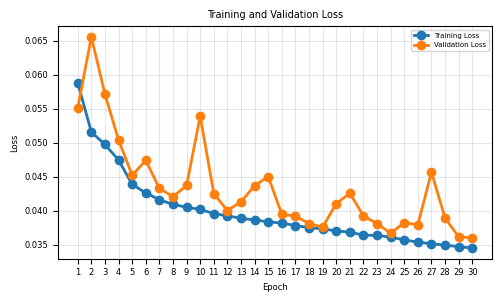

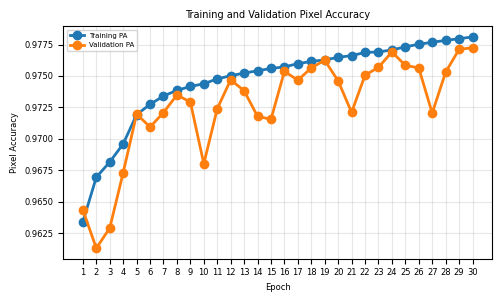

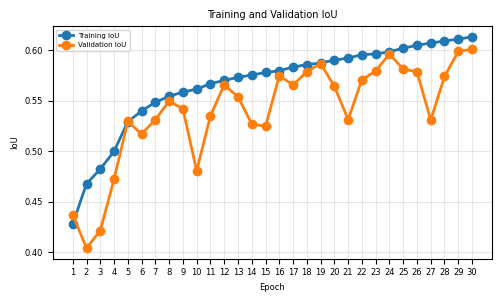

In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# Training history
# ============================================================

epochs = list(range(1, 31))

# -------------------------
# Loss
# -------------------------
train_loss = [
    0.05879852170291165,
    0.05155921211609474,
    0.04974704075473014,
    0.04746074709661785,
    0.04388160705798753,
    0.04262847949415755,
    0.041626283000542816,
    0.04093917416652622,
    0.04053096752807405,
    0.040194201695572064,
    0.039593784068856316,
    0.03926219283883884,
    0.03889480462441078,
    0.038656393697256854,
    0.03837568008122102,
    0.038193502972626636,
    0.037837872424950965,
    0.03752846251050177,
    0.03734040132524318,
    0.03704026977680701,
    0.036862391289207395,
    0.03641107787616288,
    0.036389277682575764,
    0.03613000752292031,
    0.0357307427971316,
    0.03538506889324674,
    0.03516468076178661,
    0.03494243714919705,
    0.03474818056995309,
    0.034508060272821765,
]

val_loss = [
    0.05511175525539062,
    0.06556061607073335,
    0.05712417727884124,
    0.05041117904817357,
    0.04521717004039708,
    0.04741096921703395,
    0.04329086423796766,
    0.04208011986578212,
    0.04371841782156159,
    0.05391527686048957,
    0.04253929559798802,
    0.04003627683748217,
    0.04131426815600956,
    0.04369981766623609,
    0.04502324867336189,
    0.0394935902865494,
    0.03922194198650472,
    0.03812680176514036,
    0.03759362211122232,
    0.04103953976403264,
    0.042578187234261454,
    0.039261772768462405,
    0.03810403872938717,
    0.036718309999388805,
    0.038225697769838224,
    0.037969221130890005,
    0.045668775807408725,
    0.03893963425036739,
    0.0361544224926654,
    0.036035729769398187
]

# -------------------------
# Pixel Accuracy (PA)
# -------------------------
train_pa = [
    0.9634018526751386,
    0.9669478219660801,
    0.9681540255487089,
    0.9695996977931001,
    0.9719207720548348,
    0.9727444876752128,
    0.9734024207210342,
    0.9738583254962849,
    0.9741630580222037,
    0.9743764215844088,
    0.9747710299838853,
    0.9750119517102311,
    0.9752329129439133,
    0.9754070204657477,
    0.9755972506102801,
    0.975719262433399,
    0.9759796142825962,
    0.976151480868056,
    0.9762783913007645,
    0.9764763742623359,
    0.9766207502190636,
    0.9768667603976513,
    0.9769105841860701,
    0.9770684305446807,
    0.9773159096493791,
    0.9775201668362608,
    0.9776794308188551,
    0.9778270426510277,
    0.9779612755329347,
    0.9781056594204258
]

val_pa = [
    0.9643287329112782,
    0.9613033834625693,
    0.9629031041089227,
    0.9673167810720555,
    0.9719665730700774,
    0.970938308799968,
    0.9720888376235962,
    0.973490279562333,
    0.9729238061343922,
    0.9680168579606448,
    0.9723917358061847,
    0.9746918229495778,
    0.9738220341065351,
    0.9717840952031752,
    0.9715543655788197,
    0.9753645090495839,
    0.9746619098326739,
    0.9756391525268555,
    0.9762498932726243,
    0.9746000787791084,
    0.9721034716157352,
    0.9750596803777358,
    0.9756850158467012,
    0.97690909539952,
    0.9758422262528363,
    0.9756325448260588,
    0.97204109991298,
    0.9753033680074356,
    0.9771129951757543,
    0.9772472837392021
]

# -------------------------
# IoU
# -------------------------
train_iou = [
    0.4281000305517052,
    0.4678797620869476,
    0.4823764692720901,
    0.49995362721461023,
    0.5291400208542599,
    0.5398229993182755,
    0.548428541099703,
    0.5543063625600383,
    0.5584856843626177,
    0.5613820072642979,
    0.5667280295162835,
    0.5699811037513669,
    0.5730211617669048,
    0.5753023662834802,
    0.5778310668815446,
    0.5795451900195678,
    0.583162324406253,
    0.5855413955363316,
    0.587194006928783,
    0.5900725049437208,
    0.5919680492545859,
    0.5954328804526656,
    0.5961228018614954,
    0.5982893740065133,
    0.6018085720137598,
    0.6046760470108777,
    0.6069346603757378,
    0.6088899552450359,
    0.6108582294904269,
    0.6129599924890514
]

val_iou = [
    0.43732791297576007,
    0.40426875703475057,
    0.42166821921572967,
    0.47233368719325347,
    0.5295903023551493,
    0.5168912950684043,
    0.5312188905828139,
    0.5494907568482792,
    0.5418505170766045,
    0.48062805077608894,
    0.5349161996560938,
    0.5656317812554976,
    0.5537632247980904,
    0.5270766356412102,
    0.5244991944116705,
    0.5745230601114385,
    0.5655038041227004,
    0.5784711981520934,
    0.5866282673443065,
    0.5642990003613865,
    0.5312824196675244,
    0.5707007141674266,
    0.5791957203079673,
    0.5961898624897003,
    0.5811521137461942,
    0.5784762908430661,
    0.5308343971476835,
    0.5738570094108582,
    0.598713493347168,
    0.6007219020058127
]


# ============================================================
# Plot settings
# ============================================================

plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 7,
    "axes.labelsize": 6,
    "legend.fontsize": 5,
    "figure.figsize": (5, 3)
})


# ============================================================
# 1. Loss plot
# ============================================================

plt.figure()

plt.plot(epochs, train_loss, marker="o", linewidth=2,
         label="Training Loss")

plt.plot(epochs, val_loss, marker="o", linewidth=2,
         label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 2. Pixel Accuracy plot
# ============================================================

plt.figure()

plt.plot(epochs, train_pa, marker="o", linewidth=2,
         label="Training PA")

plt.plot(epochs, val_pa, marker="o", linewidth=2,
         label="Validation PA")

plt.xlabel("Epoch")
plt.ylabel("Pixel Accuracy")
plt.title("Training and Validation Pixel Accuracy")
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("pixel_accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 3. IoU plot
# ============================================================

plt.figure()

plt.plot(epochs, train_iou, marker="o", linewidth=2,
         label="Training IoU")

plt.plot(epochs, val_iou, marker="o", linewidth=2,
         label="Validation IoU")

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Training and Validation IoU")
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("iou_curve.png", dpi=300, bbox_inches="tight")
plt.show()

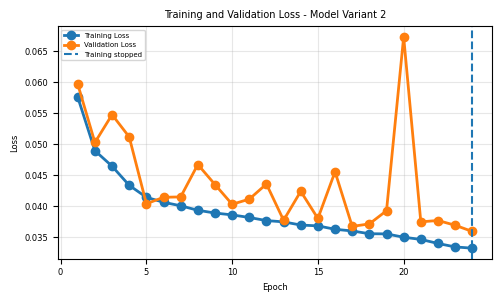

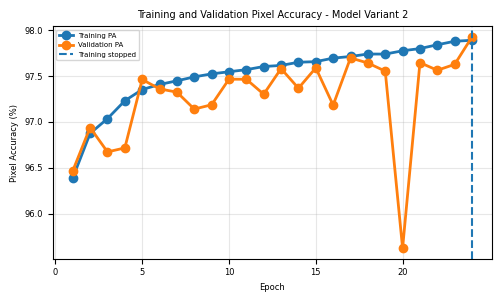

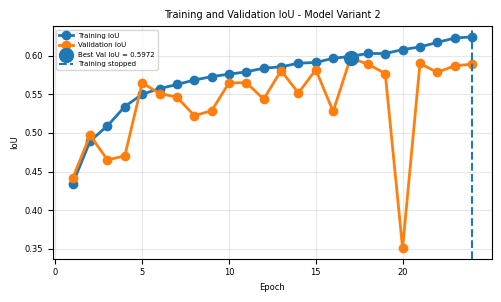

MODEL VARIANT 2 - SUMMARY
Epochs completed       : 24
Best validation IoU    : 0.597174 (Epoch 17)
Best validation loss   : 0.035955 (Epoch 24)
Best validation PA     : 97.9283% (Epoch 24)
------------------------------------------------------------
Final training loss    : 0.033258
Final validation loss  : 0.035955
Final training PA      : 97.8914%
Final validation PA    : 97.9283%
Final training IoU     : 0.624577
Final validation IoU   : 0.589165


In [ ]:


# ============================================================
# Model Variant 2 - Training History
# Completed epochs: 1-24 (intended: 50)
# ============================================================

epochs = list(range(1, 25))

# ============================================================
# Loss
# ============================================================

train_loss = [
    0.05762334223720487,
    0.04898344448877967,
    0.04648089434432636,
    0.04339593216358624,
    0.041463596676621514,
    0.04066352371567872,
    0.04009236060779952,
    0.039371655572383916,
    0.038924682904770615,
    0.038624555701215646,
    0.03820712727701714,
    0.03770423818015631,
    0.037501949964095053,
    0.0369864046775006,
    0.036856250055211745,
    0.036301719202909796,
    0.03603370957804569,
    0.0355861271439186,
    0.035560490815220655,
    0.035020698342092815,
    0.03467126198020026,
    0.03401600324360968,
    0.03345505241498258,
    0.03325816617577711,

]

val_loss = [
    0.059713661758338706,
    0.050304987807484235,
    0.05479504010256599,
    0.051203233748674394,
    0.040420315676621514,
    0.04146250311066123,
    0.041527523976915025,
    0.04675333412254558,
    0.043523044884204866,
    0.040334739842835594,
    0.04116761145346305,
    0.04360725500566118,
    0.03775685609263532,
    0.04242805325809647,
    0.03804987289888017,
    0.045588870609507844,
    0.036770104353918746,
    0.03717245799215401,
    0.03929630355799899,
    0.0673408304067219,
    0.03750442371648901,
    0.03772015391903765,
    0.036954889665631686,
    0.035954889665631686
]

# ============================================================
# Pixel Accuracy
# ============================================================

train_pa = [
    0.9638733747347477,
    0.9687464429286314,
    0.9703575280996469,
    0.9723102240949064,
    0.973535522229954,
    0.9740876616162718,
    0.9744872699904095,
    0.974917561373443,
    0.9752451017839745,
    0.9754767579001349,
    0.9757062098836204,
    0.9760488353499256,
    0.9761683312622277,
    0.976516561176078,
    0.9765800085236278,
    0.976965387125273,
    0.9771430366004579,
    0.9774124840440969,
    0.9774063581488485,
    0.9777667557127511,
    0.9780086060819407,
    0.9784237620984194,
    0.9788076271634092,
    0.978914442280474,

]

val_pa = [
    0.9646549330038183,
    0.9693885838284212,
    0.9667250563116635,
    0.9671607269960292,
    0.974632655171787,
    0.9736059322076686,
    0.9732522144037135,
    0.9714014088406282,
    0.9718733065268572,
    0.9746686654932358,
    0.9746557621394887,
    0.9730234468684477,
    0.9758221051272224,
    0.9736791421385372,
    0.9759015286670012,
    0.9718328384792103,
    0.9769858030711903,
    0.9764315016129438,
    0.975544792063096,
    0.9562169481726254,
    0.9764727662591374,
    0.9756415773840511,
    0.9762831870247336,
    0.9792831870247336
]

# ============================================================
# IoU
# ============================================================

train_iou = [
    0.43448488082225567,
    0.489466944008508,
    0.5093462070655426,
    0.5342696327677388,
    0.5502361104418979,
    0.5574842578655964,
    0.5629073952067171,
    0.5686219176606676,
    0.5731176997296775,
    0.5762208989529005,
    0.5792896685630021,
    0.5840781955609946,
    0.585727324418863,
    0.5905027105753734,
    0.5914181855636922,
    0.5968467084508924,
    0.5993145222847278,
    0.603111129850459,
    0.6029977989295912,
    0.6081036318736364,
    0.6115694897338407,
    0.617420122244254,
    0.6230982171522604,
    0.6245773837992654
]

val_iou = [
    0.44153304871390847,
    0.49706414657480574,
    0.46502868568196015,
    0.47037617809632243,
    0.5648959927699145,
    0.5511753362767836,
    0.5464802664868972,
    0.52256460926112,
    0.5287936897838816,
    0.5649991592940162,
    0.5652407278032864,
    0.5438151692642885,
    0.5809390078572666,
    0.551792418606141,
    0.5821030006689184,
    0.5279356213176951,
    0.5971744509304271,
    0.5892844817217658,
    0.5770945920663721,
    0.35070117957451763,
    0.5901343380703645,
    0.578539951057995,
    0.5871648707810571,
    0.5891648707810571
]

# ============================================================
# Find best validation IoU
# ============================================================

best_iou_epoch = epochs[val_iou.index(max(val_iou))]
best_val_iou = max(val_iou)

# Best validation loss
best_loss_epoch = epochs[val_loss.index(min(val_loss))]
best_val_loss = min(val_loss)

# Best validation PA
best_pa_epoch = epochs[val_pa.index(max(val_pa))]
best_val_pa = max(val_pa)


# ============================================================
# Plot 1: Loss
# ============================================================

plt.figure(figsize=(5, 3))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.axvline(
    x=24,
    linestyle="--",
    linewidth=1.5,
    label="Training stopped"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss - Model Variant 2")

plt.xticks(range(0, 25, 5))
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("model_variant_2_loss.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# Plot 2: Pixel Accuracy
# ============================================================

plt.figure(figsize=(5, 3))

plt.plot(
    epochs,
    [x * 100 for x in train_pa],
    marker="o",
    linewidth=2,
    label="Training PA"
)

plt.plot(
    epochs,
    [x * 100 for x in val_pa],
    marker="o",
    linewidth=2,
    label="Validation PA"
)

plt.axvline(
    x=24,
    linestyle="--",
    linewidth=1.5,
    label="Training stopped"
)

plt.xlabel("Epoch")
plt.ylabel("Pixel Accuracy (%)")
plt.title("Training and Validation Pixel Accuracy - Model Variant 2")

plt.xticks(range(0, 25, 5))
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("model_variant_2_pa.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# Plot 3: IoU
# ============================================================

plt.figure(figsize=(5, 3))

plt.plot(
    epochs,
    train_iou,
    marker="o",
    linewidth=2,
    label="Training IoU"
)

plt.plot(
    epochs,
    val_iou,
    marker="o",
    linewidth=2,
    label="Validation IoU"
)

# Mark best validation IoU
plt.scatter(
    best_iou_epoch,
    best_val_iou,
    s=100,
    zorder=5,
    label=f"Best Val IoU = {best_val_iou:.4f}"
)

plt.axvline(
    x=24,
    linestyle="--",
    linewidth=1.5,
    label="Training stopped"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Training and Validation IoU - Model Variant 2")

plt.xticks(range(0, 25, 5))
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("model_variant_2_iou.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# Print summary
# ============================================================

print("=" * 60)
print("MODEL VARIANT 2 - SUMMARY")
print("=" * 60)

print(f"Epochs completed       : {len(epochs)}")
print(f"Best validation IoU    : {best_val_iou:.6f} "
      f"(Epoch {best_iou_epoch})")

print(f"Best validation loss   : {best_val_loss:.6f} "
      f"(Epoch {best_loss_epoch})")

print(f"Best validation PA     : {best_val_pa * 100:.4f}% "
      f"(Epoch {best_pa_epoch})")

print("-" * 60)
print(f"Final training loss    : {train_loss[-1]:.6f}")
print(f"Final validation loss  : {val_loss[-1]:.6f}")

print(f"Final training PA      : {train_pa[-1] * 100:.4f}%")
print(f"Final validation PA    : {val_pa[-1] * 100:.4f}%")

print(f"Final training IoU     : {train_iou[-1]:.6f}")
print(f"Final validation IoU   : {val_iou[-1]:.6f}")
print("=" * 60)


